# What am I even doing?

None of this makes any sense, so I'm going to make it up as I go along and see what happens, because it's either that or I'm going to lose my mind.

Ok.

## What even is $k_i$?

- Everyone has a scalar. I do not have a scalar. This is probably because I am stupid. I need a scalar.
- How do you get a scalar from a time series? You integrate it. So I'm going to integrate from 0 to $t_{ind}$.

$$k_{i} = \int_0^{t_{ind}} \left [ \text{something} \right ] dt$$

- What do I integrate? Rate constants are a stupid idea. I don't care about the constants. I care about what's actually happening, and besides, can you even add forward and reverse rate constants? Probably not. idk. But, net production rate is something that gives us an idea of how much the current reaction is contributing to the chemical makeup of the next time step. I think magnitude is probably more important than direction here (i.e. how much the reaction is contributing to the state change is more important than whether it's forward or backward), so the absolute value of the net reaction rate seems like a good idea.

$$k_{i} = \int_0^{t_{ind}} \left | R_{net} \right | dt$$

- Ok but the rate by itself isn't important; what's important is the _relative_ chemical contribution of the reaction in question, so I probably want to divide by the sum of all of them at a given time step.

$$k_{i} = \frac{1}{t_{ind}} \int_0^{t_{ind}} \frac{\left | R_{net, i} \right |}{\sum_0^{N} \left | R_{net, j} \right |} dt$$

where we have normalized by the induction time to make the coefficient unitless.

So now I can get the change in integrated relative contribution between the perturbed and unperturbed state for a given equivalence ratio, diluent, and amount of dilution, and relate it to the corresponding change in cell size to get the sensitivity coefficient of the $i$th reaction, $C_{i}$.

$$\Delta k_{i} = k_{i, unperturbed} - k_{i, perturbed}$$
$$\Delta \lambda_{i} = \lambda_{i, unperturbed} - \lambda_{perturbed}$$
$$C_{s, i} = \frac{\Delta \lambda_{i}}{\Delta k_{i}}$$

Then of course I can divide by the ratio of (unperturbed) cell size to integrated chemical contribution to get the normalized sensitivity coefficient.

$$c_{s, i} = \frac{\Delta \lambda_{i}}{\Delta k_{i}} \frac{k_{i, unperturbed}}{\lambda_{unperturbed}}$$

In [1]:
import seaborn as sns
from matplotlib import pyplot as plt

from scripts.perturbation_study import data
from scripts.perturbation_study.data import SimulationResults

In [2]:
reactions = data.load_reactions()

In [3]:
reactions.unperturbed.head()

diluent dil_condition  perturbed_rxn          time  \
condition_id reaction_no                                                      
9            0              <NA>     undiluted           <NA>  0.000000e+00   
             0              <NA>     undiluted           <NA>  1.204493e-09   
             0              <NA>     undiluted           <NA>  2.408987e-09   
             0              <NA>     undiluted           <NA>  3.613480e-09   
             0              <NA>     undiluted           <NA>  5.472952e-09   

                          progress  phi_nom            reaction  \
condition_id reaction_no                                          
9            0            0.000000      1.0  2 O + M <=> O2 + M   
             0            0.001156      1.0  2 O + M <=> O2 + M   
             0            0.002313      1.0  2 O + M <=> O2 + M   
             0            0.003469      1.0  2 O + M <=> O2 + M   
             0            0.005254      1.0  2 O + M <=> O2 + M   

                          relative_chemical_contribution  
condition_id reaction_no                                  
9            0                              0.000000e+00  
             0                              9.620236e-08  
             0                              1.373804e-07  
             0                              1.464248e-07  
             0                              1.465464e-07

In [4]:
reactions.perturbed.head()

diluent dil_condition  perturbed_rxn          time  \
condition_id reaction_no                                                      
1            0              <NA>     undiluted              0  0.000000e+00   
             0              <NA>     undiluted              0  1.204493e-09   
             0              <NA>     undiluted              0  2.408987e-09   
             0              <NA>     undiluted              0  3.613480e-09   
             0              <NA>     undiluted              0  5.472952e-09   

                          progress  phi_nom            reaction  \
condition_id reaction_no                                          
1            0            0.000000      1.0  2 O + M <=> O2 + M   
             0            0.001156      1.0  2 O + M <=> O2 + M   
             0            0.002313      1.0  2 O + M <=> O2 + M   
             0            0.003469      1.0  2 O + M <=> O2 + M   
             0            0.005254      1.0  2 O + M <=> O2 + M   

                          relative_chemical_contribution  
condition_id reaction_no                                  
1            0                              0.000000e+00  
             0                              9.139224e-08  
             0                              1.305114e-07  
             0                              1.391035e-07  
             0                              1.392191e-07

In [5]:
conditions = data.load_conditions()

In [6]:
conditions.unperturbed.head()

,dil_condition,phi_nom,diluent,equivalence,dil_mf,cell_size,perturbed_rxn,perturbation_fraction
condition_id,,,,,,,,
9,undiluted,1.0,<NA>,1.0,0.0,0.006102,<NA>,0.0
327,low,1.0,CO2,1.0,0.1,0.015682,<NA>,0.0
653,high,1.0,CO2,1.0,0.2,0.045444,<NA>,0.0
979,low,1.0,CO2i,1.0,0.1,0.01552,<NA>,0.0
1305,high,1.0,CO2i,1.0,0.2,0.045132,<NA>,0.0


In [7]:
conditions.perturbed.head()

,dil_condition,phi_nom,diluent,equivalence,dil_mf,cell_size,perturbed_rxn,perturbation_fraction
condition_id,,,,,,,,
1,undiluted,1.0,<NA>,1.0,0.0,0.006102,0,-0.05
2,undiluted,1.0,<NA>,1.0,0.0,0.006103,26,-0.05
3,undiluted,1.0,<NA>,1.0,0.0,0.006102,4,-0.05
4,undiluted,1.0,<NA>,1.0,0.0,0.006102,15,-0.05
5,undiluted,1.0,<NA>,1.0,0.0,0.006103,17,-0.05


In [8]:
conditions.unperturbed

,dil_condition,phi_nom,diluent,equivalence,dil_mf,cell_size,perturbed_rxn,perturbation_fraction
condition_id,,,,,,,,
9,undiluted,1.0,<NA>,1.0,0.000000,0.006102,<NA>,0.0
327,low,1.0,CO2,1.0,0.100000,0.015682,<NA>,0.0
653,high,1.0,CO2,1.0,0.200000,0.045444,<NA>,0.0
979,low,1.0,CO2i,1.0,0.100000,0.01552,<NA>,0.0
1305,high,1.0,CO2i,1.0,0.200000,0.045132,<NA>,0.0
1631,low,1.0,N2,1.0,0.204576,0.01156,<NA>,0.0
1957,high,1.0,N2,1.0,0.351871,0.021676,<NA>,0.0
2283,low,1.0,N2i,1.0,0.204576,0.011557,<NA>,0.0
2608,high,1.0,N2i,1.0,0.351871,0.02167,<NA>,0.0


In [9]:
coefficients = data.calculate_coefficients(conditions, reactions)

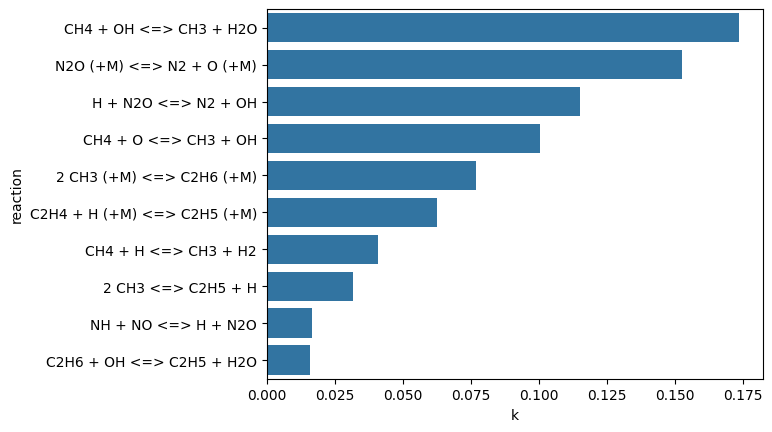

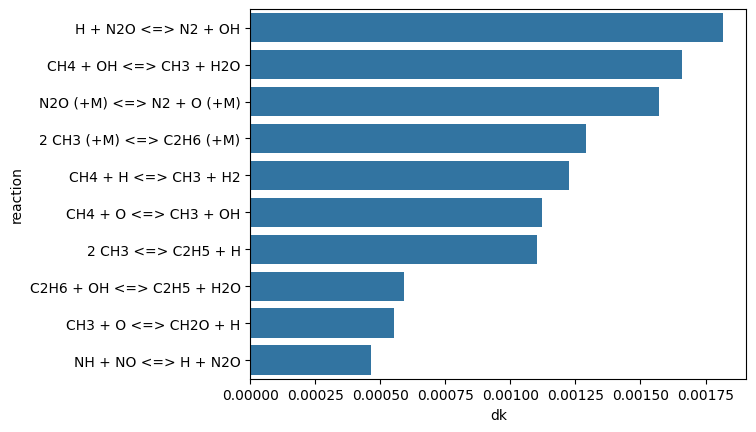

In [12]:
for target in ("k", "delta_k"):
    plt.figure()
    sns.barplot(
        x=target,
        y="reaction",
        data=(
            coefficients[coefficients.index.to_frame().diluent.isna()]
            .nlargest(10, target)
        ),
        orient="h",
    )